In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from psr import estimate_delay_ami, estimate_dimension_fnn, AMIConfig, FNNConfig

# Part A `Phase Space Reconstruction (PSR)`

## A.2 Time Delay via Average Mutual Information (AMI)

Following the indexing in the task file

### A.2.1 Generating the Lorenz Time-Series Data

#### A.2.1.1 Defining the Lorenz Time Series

In [23]:
def lorenz(t, state, sigma, rho, beta):
    """The Lorenz system differential equations."""
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

#### A.2.1.2 Configurations

In [24]:
# Simulation parameters
dt = 0.01          # Integration time step (as used in task 1)
n_transient = 2000 # Steps to discard to ensure we are on the attractor
n_samples = 15000  # Number of samples for analysis (>= 10,000 required)
total_steps = n_transient + n_samples
sigma, rho, beta = 10.0, 28.0, 8.0/3.0
parameters = (sigma, rho, beta)


# Time span and evaluation points
t_span = (0, total_steps * dt)
t_eval = np.linspace(0, total_steps * dt, total_steps)
initial_state = [1.0, 1.0, 1.0]

#### A.2.1.3 Generating the Time-Series data (executing the Lorenz system)

In [25]:
def rk4_step(derivs, state, t, dt, params):
    """Calculates one RK4 step."""
    k1 = dt * derivs(t, state, *params)
    k2 = dt * derivs(t + dt/2, state + k1/2, *params)
    k3 = dt * derivs(t + dt/2, state + k2/2, *params)
    k4 = dt * derivs(t + dt, state + k3, *params)
    return state + (k1 + 2*k2 + 2*k3 + k4) / 6.0

def simulate_flow(derivs, initial_condition, T, dt, params):
    """Runs the simulation over time T."""
    steps = int(T / dt) # steps = total_steps
    states = np.zeros((steps, len(initial_condition)))
    states[0] = initial_condition
    time_vals = np.linspace(0, T, steps)
    
    for i in range(1, steps):
        states[i] = rk4_step(derivs, states[i-1], time_vals[i-1], dt, params)
        
    return time_vals, states

In [26]:
t_lor, states_lor = simulate_flow(lorenz, initial_state, total_steps * dt, dt, parameters)  # total_steps * dt = total_time (T)

In [27]:
# This method using the solve_ivp scipy method, takes too much time, it too (62 minutes and still didn't finish)
# solution = solve_ivp(lorenz_ode, t_span, initial_state, t_eval=t_eval, method='RK45')

#### A.2.1.4 Extracting the scalar 1-D time series (x-coordinate) and discarding the transient

In [28]:
# extracting the full x-coordinate history (all rows, column 0)  x indexed at column 0, y at column 1, z at column 2
x_full = states_lor[:, 0]

# slicing off the transient period (the first 2000 steps)
x_series = x_full[n_transient:]

# Extracting the data (associated with the scipy solve_ivp method)
# x_full = solution.y[0]
# x_series = x_full[n_transient:]

### A.2.2 Estimating Time Delay (AMI) `Average Mutual Information`

In [29]:
# defining the AMI configurations
ami_cfg = AMIConfig(max_lag=150, n_bins=32, criterion='first_local_min')

# estimate_delay_ami returns the optimal delay, the array of lags, and the AMI values
tau_opt, lags, ami_vals = estimate_delay_ami(x_series, cfg=ami_cfg, standardize=True)
print(f"Optimal time delay (tau): {tau_opt}")

Optimal time delay (tau): 17


#### A.2.2.1 Plotting AMI

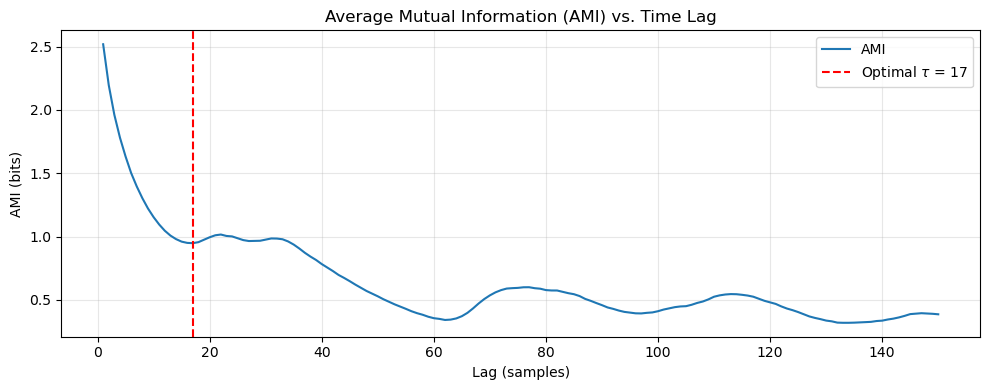

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(lags, ami_vals, label='AMI')
plt.axvline(tau_opt, color='red', linestyle='--', label=f'Optimal $\\tau$ = {tau_opt}')
plt.title('Average Mutual Information (AMI) vs. Time Lag')
plt.xlabel('Lag (samples)')
plt.ylabel('AMI (bits)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## A.3 Embedding Dimension via False Nearest Neighbours (FNN)

### A.3.1 Configuring the FNN

In [31]:
print(f"Running False Nearest Neighbours (FNN) with tau={tau_opt}...")

# Calculate approximate mean orbital period for the Theiler window
# A simple heuristic for Lorenz is the dominant frequency of the x-series

zero_crossings = np.where(np.diff(np.sign(x_series - np.mean(x_series))))[0]
mean_period = int(np.mean(np.diff(zero_crossings)) * 2) 
print(f"Estimated mean orbital period for Theiler window: {mean_period} samples")

fnn_cfg = FNNConfig(
    max_dim=10, 
    R_tol=10.0, 
    A_tol=2.0, 
    threshold_percent=1.0, 
    theiler=50 # mean_period  # Exclude points on the same trajectory loop
)

Running False Nearest Neighbours (FNN) with tau=17...
Estimated mean orbital period for Theiler window: 307 samples


### A.3.2 Estimating the dimensions using the FNN

In [32]:
# estimate_dimension_fnn returns optimal dimension, dimensions tested, and FNN percentages
m_opt, dims, fnn_pct = estimate_dimension_fnn(x_series, tau=tau_opt, cfg=fnn_cfg, standardize=True)
print(f"Optimal embedding dimension (m): {m_opt}")

Optimal embedding dimension (m): 3


### A.3.3 Plotting FNN

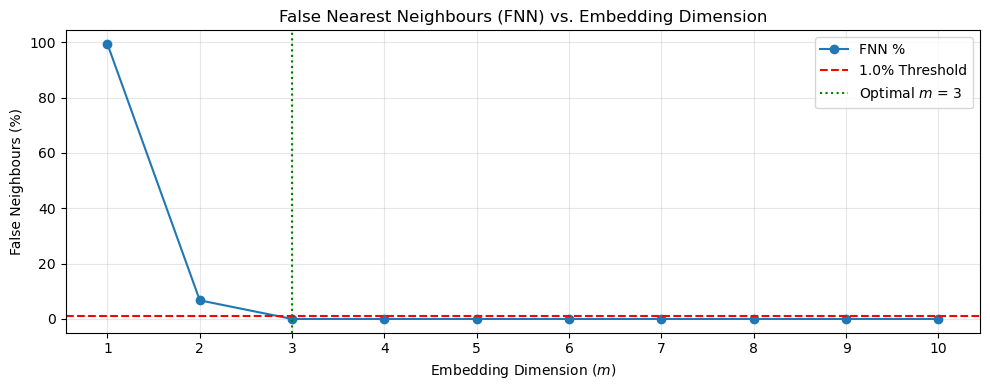

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(dims, fnn_pct, marker='o', linestyle='-', label='FNN %')
plt.axhline(fnn_cfg.threshold_percent, color='red', linestyle='--', label='1.0% Threshold')
plt.axvline(m_opt, color='green', linestyle=':', label=f'Optimal $m$ = {m_opt}')
plt.title('False Nearest Neighbours (FNN) vs. Embedding Dimension')
plt.xlabel('Embedding Dimension ($m$)')
plt.ylabel('False Neighbours (%)')
plt.xticks(dims)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Part B `Lyapunov Exponent`

If we start two identical chaotic systems at tiny different starting points, their trajectories will diverge `exponentially` over time.  
The Lyapunov exponent **λ** measures **the exact rate of divergence between them**.

`Trajectories`: the time-series data that consistes of the system states every time-step.

In [34]:
import time
from lyapunov import (
    lyapunov_wolf_ode, wolf_mle, 
    AttractorODEConfig, WolfODEConfig, WolfConfig
)

## B.2 Lyapunov Spectrum from ODE

ODE means (Ordinary Differential Equations) which are the equations in Lorenze system for example.  
Here we calculate the Lyap. spectrum (which are λ₁, λ₂, λ3) which are the Lyap. exponent for x, y and z.

We calculate it on the synthitic data that has no noise and w know its equation.  
So it is easy to calculate as we have the equations used for generating the time-series data.

In [ ]:
def lorenz(state, t, sigma, rho, beta):
    x, y, z = state
    return np.array([sigma*(y-x), x*(rho-z)-y, x*y-beta*z])

def lorenz_jac(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """Analytic Jacobian of the Lorenz system."""
    x, y, z = state
    return np.array([
        [-sigma, sigma, 0],
        [rho - z, -1, -x],
        [y, x, -beta]
    ])

print("\nCalculating 'Ground Truth' Spectrum from ODE...")
ode_cfg = AttractorODEConfig(
    ode=lorenz, 
    jacobian=lorenz_jac,
    x0=np.array([1.0, 1.0, 1.0]), 
    params=(10.0, 28.0, 8.0/3.0),
    dt=0.01, 
    transient_steps=2000, 
    n_steps=30000, 
    solver=None # Triggers the fast manual RK4 inside lyapunov_wolf_ode
)

# Using log_base='2' to get bits/time for direct comparison
wolf_ode_cfg = WolfODEConfig(ortho_steps=20, log_base='2')
spectrum = lyapunov_wolf_ode(ode_cfg, wolf_cfg=wolf_ode_cfg)

print(f"Full Lyapunov Spectrum (bits/time): {spectrum}")
print(f"Largest Lyapunov Exponent (ODE): {spectrum[0]:.4f} bits/time")


Calculating 'Ground Truth' Spectrum from ODE...
Full Lyapunov Spectrum (bits/time): [ 1.29482562e+00 -3.80432195e-03 -2.10077070e+01]
Largest Lyapunov Exponent (ODE): 1.2948 bits/time


## B.3 LLE from Time Series (MLE)

Here we use the `Wolf's Phase-Space Tracking` method to calculate the Lyapunov exponent real-world time-series data that we do not know its equations (ODE)  
By reconstructing the phase space `(projecting the data to multiple dimensions)` and tracking how reconstructed phase space points drift apart.  

We use the x-coorinate data of the Lorenz equation as the real-world data, and reconstruct the y and z, then calculate the Lyapunov exp.

In [36]:
print("\nEstimating Largest Lyapunov Exponent from Time Series...")
# actual outputs you got from part A
tau_opt_from_part_a = tau_opt
m_opt_from_part_a = m_opt

mle_cfg = WolfConfig(
    min_dist_scale=1e-3, 
    max_dist_scale=1e-1,
    evolve_cap=50, 
    max_replacements=300, 
    angle_weight=0.3
)

mle_estimate, debug_info = wolf_mle(
    x_series, 
    dt=0.01, 
    tau=tau_opt_from_part_a, 
    m=m_opt_from_part_a, 
    cfg=mle_cfg, 
    return_debug=True
)

print(f"Largest Lyapunov Exponent (Time Series): {mle_estimate:.4f} bits/time")
print(f"Segments tracked (replacements): {debug_info['replacements']}")


Estimating Largest Lyapunov Exponent from Time Series...
Largest Lyapunov Exponent (Time Series): 2.2995 bits/time
Segments tracked (replacements): 299


## Part C & D

* C_m(r) "correlation sum"
* K2 Entropy
* D2

(Kolmogorov **`K2`** Entropy): **how fast a system loses its predictability** (or how fast it produces new information)**.**  
Another definition: **If you know the state of the system perfectly now, how quickly does that certainty degrade into chaos.**


A chaotic attractor is a **fractal**, meaning it has a `non-integer` dimension (it is more complex than a 2D plane but doesn't fully fill a 3D volume). The Grassberger-Procaccia algorithm measures this "density" or "thickness".

## C_D.1 Setup & GP Algorithm (Correlation Sum)

In [37]:
from scipy.spatial.distance import pdist, squareform
from psr import reconstruct_matrix


def compute_correlation_sum(X, r_vals, theiler):
    """
    Computes the correlation sum C(r) for a given reconstructed phase space.
    """
    N = len(X)
    # To keep memory usage low and execution fast, we cap the samples analyzed.
    # 5000 points yield ~12.5 million unique pairs, which is plenty for scaling.
    n_points = min(N, 5000)
    X_sub = X[:n_points]
    
    # Calculate all pairwise distances natively
    dists = squareform(pdist(X_sub, metric='euclidean'))
    
    # Apply Theiler window to exclude temporally close pairs
    for i in range(n_points):
        start = max(0, i - theiler)
        end = min(n_points, i + theiler + 1)
        dists[i, start:end] = np.inf # Set to infinity so they are ignored
        
    valid_mask = dists < np.inf
    total_valid_pairs = np.sum(valid_mask)
    
    C_r = np.zeros(len(r_vals))
    for k, r in enumerate(r_vals):
        # Count fraction of valid pairs closer than radius r
        C_r[k] = np.sum(dists[valid_mask] < r) / total_valid_pairs
        
    return C_r

# using parameters from part A, (Already defined above)
# tau_opt = 13
# m_opt = 3     
mean_period = 70 # Theiler window from Part A
dt = 0.01

# Define embedding dimensions to test to confirm saturation
dims_to_test = [m_opt, m_opt + 1, m_opt + 2, m_opt + 3, m_opt + 4, m_opt + 5]

# Reconstruct a temporary matrix to find the attractor's physical diameter
X_temp = reconstruct_matrix(x_series, tau=tau_opt, d=m_opt)
diameter = np.max(pdist(X_temp[:1000]))

# Generate logarithmically spaced radii (0.1% to 50% of diameter)
r_vals = np.geomspace(diameter * 0.001, diameter * 0.5, 40)
log_r = np.log(r_vals)

# Store results
C_r_dict = {}
D2_estimates = []

## C_D.2 Compute C(r) for each dimension

In [38]:
print("Computing Correlation Sums for different embedding dimensions...")
for m in dims_to_test:
    X_m = reconstruct_matrix(x_series, tau=tau_opt, d=m)
    C_r = compute_correlation_sum(X_m, r_vals, theiler=mean_period)
    
    # Filter out absolute zeros to avoid log(0) warnings
    valid_idx = C_r > 0
    C_r_dict[m] = {
        'C_r': C_r,
        'log_r': log_r[valid_idx],
        'log_Cr': np.log(C_r[valid_idx]),
        'valid_idx': valid_idx
    }

Computing Correlation Sums for different embedding dimensions...


## Part D `Correlation Dimension (D2)`

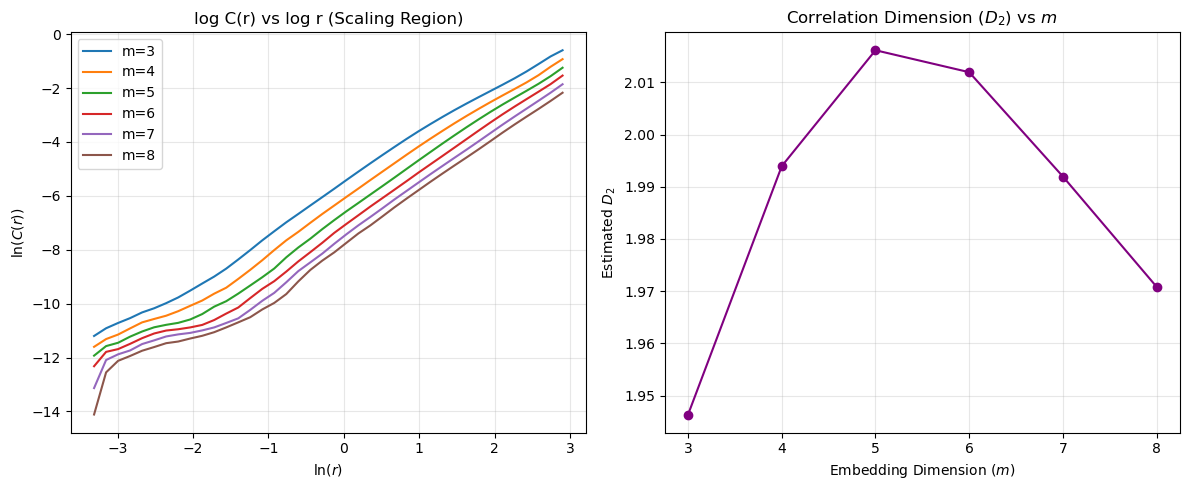


--- Part D Output ---
D2 for m=3: 1.9464
D2 for m=4: 1.9940
D2 for m=5: 2.0162
D2 for m=6: 2.0120
D2 for m=7: 1.9920
D2 for m=8: 1.9708
In the 'D2' VS. 'm' plot. The value should saturate (flatten) for chaotic systems.


In [39]:
plt.figure(figsize=(12, 5))

# Plot 1: log C(r) vs log r
plt.subplot(1, 2, 1)
for m in dims_to_test:
    data = C_r_dict[m]
    plt.plot(data['log_r'], data['log_Cr'], label=f'm={m}')
    
    # Estimate D2 using the gradient (slope) of the middle "linear" scaling region
    # We trim the edges (top and bottom 20%) where the curve flattens due to finite data
    trim = int(len(data['log_r']) * 0.2)
    if len(data['log_r']) > 2 * trim:
        slope = np.polyfit(data['log_r'][trim:-trim], data['log_Cr'][trim:-trim], 1)[0]
        D2_estimates.append(slope)
    else:
        D2_estimates.append(np.nan)

plt.title('log C(r) vs log r (Scaling Region)')
plt.xlabel('$\ln(r)$')
plt.ylabel('$\ln(C(r))$')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: D2 vs embedding dimension m[cite: 1]
plt.subplot(1, 2, 2)
plt.plot(dims_to_test, D2_estimates, 'o-', color='purple')
plt.title('Correlation Dimension ($D_2$) vs $m$')
plt.xlabel('Embedding Dimension ($m$)')
plt.ylabel('Estimated $D_2$')
plt.xticks(dims_to_test)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Part D Output ---")
for m, d2 in zip(dims_to_test, D2_estimates):
    print(f"D2 for m={m}: {d2:.4f}")
print("In the 'D2' VS. 'm' plot. The value should saturate (flatten) for chaotic systems.")

## Part C `Kolmogorov (K2) Entropy`

Formula: K2 = -(1/dt) * ln( C_m(r) / C_{m+1}(r) )


==========Part C Output==========
Estimated K2 (from m=3 to 4): -62.1329
Estimated K2 (from m=4 to 5): -53.6835
Estimated K2 (from m=5 to 6): -46.0435
Estimated K2 (from m=6 to 7): -36.7287
Estimated K2 (from m=7 to 8): -28.2290


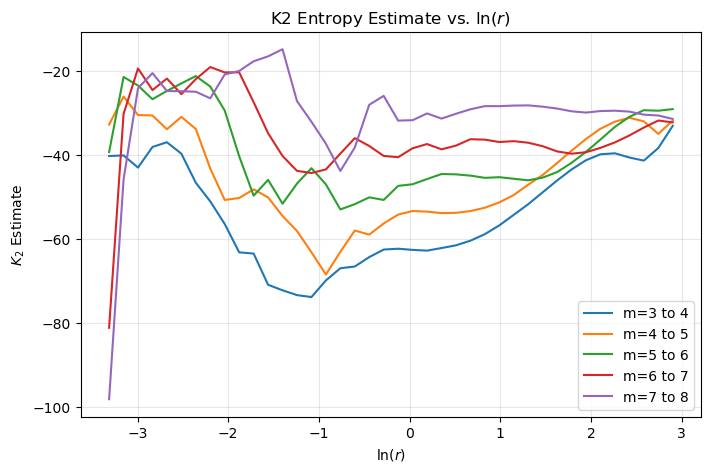

In [40]:
print("\n==========Part C Output==========")
plt.figure(figsize=(8, 5))

for i in range(len(dims_to_test) - 1):
    m_curr = dims_to_test[i]
    m_next = dims_to_test[i+1]
    
    # We need matching radii between the two dimensions
    valid_curr = C_r_dict[m_curr]['C_r'] > 0
    valid_next = C_r_dict[m_next]['C_r'] > 0
    valid_both = valid_curr & valid_next
    
    C_m = C_r_dict[m_curr]['C_r'][valid_both]
    C_m_plus_1 = C_r_dict[m_next]['C_r'][valid_both]
    r_valid = r_vals[valid_both]
    
    # Calculate K2 across the valid radii[cite: 1]
    K2_curve = -(1.0 / dt) * np.log(C_m / C_m_plus_1)
    
    plt.plot(np.log(r_valid), K2_curve, label=f'm={m_curr} to {m_next}')
    
    # Average K2 over the same central scaling region used for D2
    trim = int(len(K2_curve) * 0.2)
    if len(K2_curve) > 2 * trim:
        K2_est = np.mean(K2_curve[trim:-trim])
        print(f"Estimated K2 (from m={m_curr} to {m_next}): {K2_est:.4f}")

plt.title('K2 Entropy Estimate vs. $\ln(r)$')
plt.xlabel('$\ln(r)$')
plt.ylabel('$K_2$ Estimate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Part E `(Fractal (Box-Counting) Dimension)`

Reconstructing phase space for Box-Counting...
Counting occupied boxes...


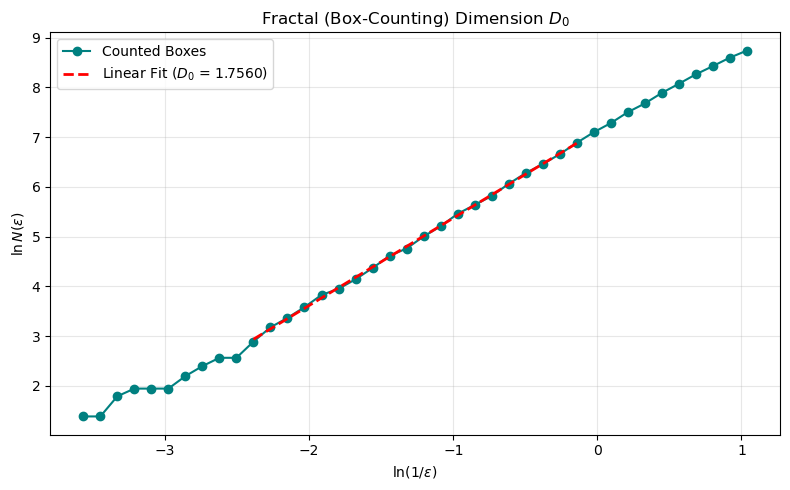

Estimated Box-Counting Dimension (D0): 1.7560


In [41]:
from psr import reconstruct_matrix

# 1. Prepare the Data
# Use the same optimal parameters you found in Part A
tau_opt = 13  
m_opt = 3     

print("Reconstructing phase space for Box-Counting...")
X = reconstruct_matrix(x_series, tau=tau_opt, d=m_opt)

# 2. Determine Box Sizes (epsilons)
# Find the physical bounds of the attractor in the reconstructed space
min_val = np.min(X, axis=0)
max_val = np.max(X, axis=0)
diameter = np.max(max_val - min_val)

# Generate logarithmically spaced box sizes from 100% of diameter down to 1%
epsilons = np.geomspace(diameter * 1.0, diameter * 0.01, 40)
N_eps = []

# 3. Count the Boxes
print("Counting occupied boxes...")
for eps in epsilons:
    # Shift data to origin, divide by box size, and floor to an integer.
    # This perfectly groups nearby points into identical integer coordinates (boxes).
    boxes = np.floor((X - min_val) / eps).astype(int)
    
    # Count how many unique coordinate vectors exist
    unique_boxes = np.unique(boxes, axis=0)
    N_eps.append(len(unique_boxes))

# 4. Extract the Dimension (D0)
# Convert arrays for the log-log plot
ln_N = np.log(N_eps)
ln_1_over_eps = np.log(1.0 / epsilons)

# We isolate the linear scaling region by trimming the extreme ends.
# At very large eps, N=1 (everything in one box). At very small eps, N = total points.
trim = int(len(epsilons) * 0.25)
valid_x = ln_1_over_eps[trim:-trim]
valid_y = ln_N[trim:-trim]

# Calculate the slope (D0) using a degree-1 polynomial fit
slope, intercept = np.polyfit(valid_x, valid_y, 1)
D0 = slope

# 5. Plotting the Results
plt.figure(figsize=(8, 5))
plt.plot(ln_1_over_eps, ln_N, 'o-', color='teal', label='Counted Boxes')
plt.plot(valid_x, intercept + D0 * valid_x, 'r--', linewidth=2, label=f'Linear Fit ($D_0$ = {D0:.4f})')

plt.title('Fractal (Box-Counting) Dimension $D_0$')
plt.xlabel('$\ln(1/\epsilon)$')
plt.ylabel('$\ln N(\epsilon)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Estimated Box-Counting Dimension (D0): {D0:.4f}")